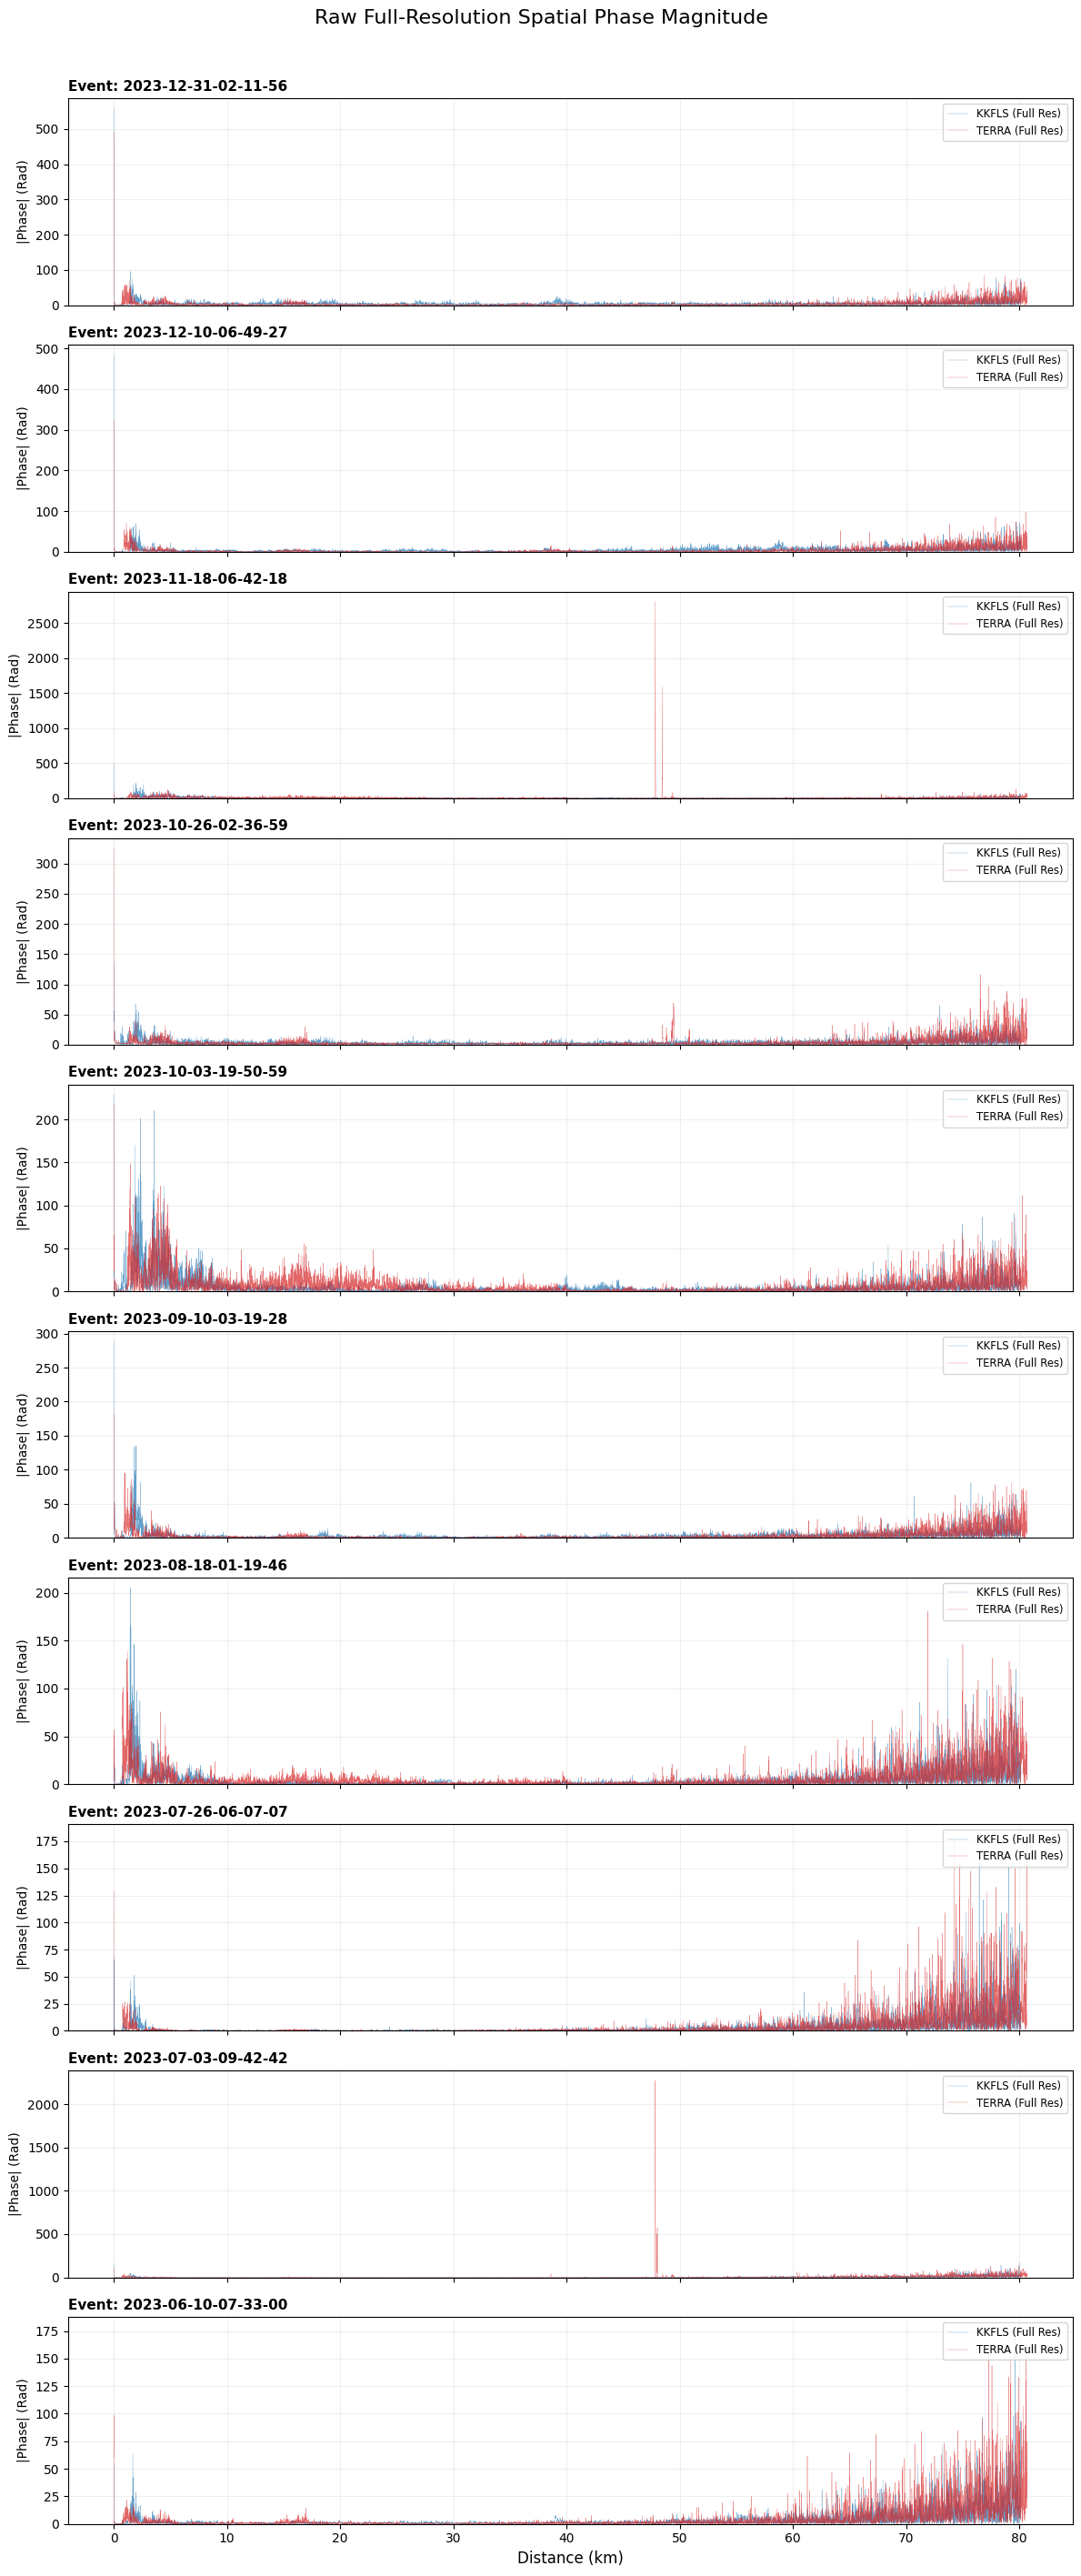

In [1]:
# 'flat' raw noise profiles

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dascore as dc
import os

def load_coords(filepath):
    df = pd.read_csv(filepath, sep=r'\s+', header=None, names=['lon','lat','cha','dep']).dropna()
    df['lon'] = df['lon'].apply(lambda x: x - 360 if x > 180 else x)
    R = 6371.0
    lat, lon = np.radians(df['lat'].values), np.radians(df['lon'].values)
    dlat, dlon = np.diff(lat), np.diff(lon)
    a = np.sin(dlat/2)**2 + np.cos(lat[:-1])*np.cos(lat[1:])*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    df['dist_km'] = np.insert(R * c, 0, 0).cumsum()
    return df

def get_full_res_array(f_path, coords_df):
    """
    For a given cable, calculates every channel's absolute median and saves it to an array for plotting.
    """
    if not os.path.exists(f_path): return None, None
    try:
        patch = dc.spool(f_path)[0]
        sub = patch.select(time=(patch.coords.max('time') - np.timedelta64(45, 's'), 
                                 patch.coords.max('time')))
        # absolute value of 'raw' median
        raw_median = np.squeeze(sub.median(dim="time").data)
        ky_abs = np.abs(raw_median)
        kx_raw = coords_df['dist_km'].values
        #print(patch.attrs) # needed it for a quick check earlier 
        
        # prevents dimension mismatch via trimming
        min_len = min(len(kx_raw), len(ky_abs))
        return kx_raw[:min_len], ky_abs[:min_len]
    except Exception as e:
        print(f"Error: {e}")
        return None, None

base_dir = "/Users/ed/research_code/das"
noise_game_dir = os.path.join(base_dir, "das_records")
event_list = [
    "2023-12-31-02-11-56.537000ML1.5", 
    "2023-12-10-06-49-27.068000ML1.4",
    "2023-11-18-06-42-18.743000ML1.8", 
    "2023-10-26-02-36-59.823000ML1.3",
    "2023-10-03-19-50-59.443000ML1.4", 
    "2023-09-10-03-19-28.336000ML1.4",
    "2023-08-18-01-19-46.681000ML1.3", 
    "2023-07-26-06-07-07.039000ML1.2",
    "2023-07-03-09-42-42.845000ML1.5", 
    "2023-06-10-07-33-00.219000ML1.9"
]

kkfls_coords = load_coords(os.path.join(base_dir, 'das_coords_bathymetry/KKFLS_coords.xycz'))
terra_coords = load_coords(os.path.join(base_dir, 'das_coords_bathymetry/TERRA_coords.xycz'))

fig, axes = plt.subplots(10, 1, figsize=(12, 28), sharex=True)
plt.subplots_adjust(hspace=0.5)

for i, eid in enumerate(event_list):
    ax = axes[i]
    kx, ky = get_full_res_array(os.path.join(noise_game_dir, f"{eid}KKFLS"), kkfls_coords)
    if kx is not None:
        ax.plot(kx, ky, color='tab:blue', lw=0.25, alpha=0.7, label="KKFLS (Full Res)")

    tx, ty = get_full_res_array(os.path.join(noise_game_dir, f"{eid}TERRA"), terra_coords)
    if tx is not None:
        ax.plot(tx, ty, color='tab:red', lw=0.25, alpha=0.7, label="TERRA (Full Res)")
    
    ax.set_title(f"Event: {eid[:19]}", loc='left', fontweight='bold', fontsize=11)
    ax.set_ylabel("|Phase| (Rad)", fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.legend(loc='upper right', fontsize='small')
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Distance (km)", fontsize=12)
plt.suptitle("Raw Full-Resolution Spatial Phase Magnitude", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()